In [1]:
import os

from charset_normalizer.cli import query_yes_no

os.environ["SCIPY_ARRAY_API"] = "1"

import pandas as pd
import numpy as np
import seaborn as sns

from dpks import QuantMatrix

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial")


In [2]:
selected_features = pd.read_csv(
    "sepsis_feature_importances.tsv",
    sep="\t",
)['feature'].to_list()

In [3]:

def preprocess_design_matrix(design_matrix):

    # design_matrix = design_matrix[
    #     ((design_matrix['Sepsis Diagnosis Probability'] >= 0.8) | 
    #     (design_matrix['Sepsis Diagnosis Probability'] <= 0.50))
    # ].copy()

    design_matrix['group'] = 1

    design_matrix['sample'] = design_matrix['injection']

    return design_matrix

In [4]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_clinical_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()
    
    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_clinical_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix.annotate()     


In [5]:
ms_data = pd.read_csv(
    "../1_proteomics_data/protein_test_filtered.tsv"
    , sep="\t"
)

In [6]:
design_matrix = pd.read_csv(
    "../0_clinical_data/design_matrix_test.tsv",
    sep='\t'
)

In [7]:
ms_data_test = pd.read_csv(
    "../1_proteomics_data/protein_val_filtered.tsv"
    , sep="\t"
)
design_matrix_test = pd.read_csv(
    "../0_clinical_data/design_matrix_validation.tsv",
    sep='\t'
)

(253, 73)

In [8]:
design_matrix_test = design_matrix_test[design_matrix_test['injection'].isin(ms_data_test.columns)].copy()

In [9]:
design_matrix['survival_30_day'] = np.where(design_matrix['survival_days'] <= 30, 1, 0)
design_matrix_test['survival_30_day'] = np.where(design_matrix_test['survival_days'] <= 30, 1, 0)


design_matrix['future_deterioration'] = np.where(
    (design_matrix['sofa_score_increase_day2'] > 1) & (design_matrix['sofa_score_increase_day3'] > 1), 1, 0
)
design_matrix_test['future_deterioration'] = np.where(
    (design_matrix_test['sofa_score_increase_day2'] > 1) & (design_matrix_test['sofa_score_increase_day3'] > 1), 1, 0
)


In [10]:
design_matrix_train = preprocess_design_matrix(design_matrix)

quant_matrix_train = preprocess_data(ms_data, design_matrix=design_matrix_train)

In [11]:
quant_matrix_train_df = quant_matrix_train.to_df()
quant_matrix_train_df = quant_matrix_train_df[quant_matrix_train_df['ProteinLabel'].isin(selected_features)]

In [12]:
qm_filtered_train = (

    QuantMatrix(
        quantification_file=quant_matrix_train_df,
        design_matrix_file=design_matrix_train
    )

)

In [13]:
training_data, y = qm_filtered_train.to_ml(feature_column="ProteinLabel")

In [14]:
training_data = training_data.join(
    design_matrix_train.set_index("injection")
)

In [15]:
design_matrix_test = preprocess_design_matrix(design_matrix_test)

quant_matrix_test = preprocess_data(ms_data_test, design_matrix=design_matrix_test)

In [16]:
quant_matrix_test_df = quant_matrix_test.to_df()
quant_matrix_test_df = quant_matrix_test_df[quant_matrix_test_df['ProteinLabel'].isin(selected_features)]

In [17]:
qm_filtered_test = (
    
    QuantMatrix(
        quantification_file=quant_matrix_test_df,
        design_matrix_file=design_matrix_test
    )
    
)

In [18]:
testing_data, y_test = qm_filtered_test.to_ml(feature_column="ProteinLabel")

In [19]:
testing_data = testing_data.join(
    design_matrix_test.set_index("injection")
)

In [20]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer, MinMaxScaler
from sklearn.impute import SimpleImputer

protein_scaler = StandardScaler()

training_data[selected_features] = protein_scaler.fit_transform(training_data[selected_features])
testing_data[selected_features] = protein_scaler.transform(testing_data[selected_features])

In [21]:
training_data = training_data.reset_index(drop=True)

In [22]:
testing_data = testing_data.reset_index(drop=True)

In [23]:
from dfmodel import DigitalFamilyBinary

df_estimator = DigitalFamilyBinary(
    n_neighbors=10,
    neighbor_metric="euclidean",
    bootstrap_iterations=1000,
)

df_estimator.fit(training_data, features=selected_features)

In [24]:
training_data['Sepsis Rates'] = df_estimator.predict(training_data, features=selected_features, target_column="sepsis_or_septic_shock", bootstrap=True)
training_data['Infection Rates'] = df_estimator.predict(training_data, features=selected_features, target_column="verified_infection", bootstrap=True)
training_data['Future Organ Dysfunction'] = df_estimator.predict(training_data, features=selected_features, target_column="future_deterioration", bootstrap=True)
training_data['30 Day Mortality'] = df_estimator.predict(training_data, features=selected_features, target_column="survival_30_day", bootstrap=True)
training_data['ICU'] = df_estimator.predict(training_data, features=selected_features, target_column="critical_care", bootstrap=True)

In [25]:
testing_data['Sepsis Rates'] = df_estimator.predict(testing_data, features=selected_features, target_column="sepsis_or_septic_shock", bootstrap=True)
testing_data['Infection Rates'] = df_estimator.predict(testing_data, features=selected_features, target_column="verified_infection", bootstrap=True)
testing_data['Future Organ Dysfunction'] = df_estimator.predict(testing_data, features=selected_features, target_column="future_deterioration", bootstrap=True)
organ_dysfunction_bootstrap_df = df_estimator.bootstrap_results_df.copy()
testing_data['30 Day Mortality'] = df_estimator.predict(testing_data, features=selected_features, target_column="survival_30_day", bootstrap=True)
mortality_bootstrap_df = df_estimator.bootstrap_results_df.copy()
testing_data['ICU'] = df_estimator.predict(testing_data, features=selected_features, target_column="critical_care", bootstrap=True)
icu_bootstrap_df = df_estimator.bootstrap_results_df.copy()

In [26]:
organ_dysfunction_bootstrap_df.join(
    testing_data
).to_csv(
    "pod_bootstrap_results_df.csv",
)

mortality_bootstrap_df.join(
    testing_data
).to_csv(
    "mortality_bootstrap_results_df.csv",
)

icu_bootstrap_df.join(
    testing_data
).to_csv(
    "icu_bootstrap_results_df.csv",
)

In [27]:
future_organ_mean = training_data['Future Organ Dysfunction'].mean()
future_organ_std = training_data['Future Organ Dysfunction'].std()

In [28]:
organ_dys_cutoff = future_organ_mean - future_organ_std
organ_dys_cutoff

0.12836376338756864

In [29]:
import heapq

def goal(graph, node):

    for n in graph.neighbors(node):
        if graph.nodes[n]['Future Organ Dysfunction'] > organ_dys_cutoff:
            return False
    return True

def heuristic(graph, u, v):

    u_data = np.array([graph.nodes[u][col] for col in selected_features])
    v_data = np.array([graph.nodes[v][col] for col in selected_features])

    return np.linalg.norm(u_data - v_data) # returns Euclidean distance between target and source


def find_path(graph, source):

    visited = set()

    queue = [(0, source, [source])]

    heapq.heapify(queue)

    while queue:

        cost, current, path = heapq.heappop(queue)

        if goal(graph, current):

            return path

        visited.add(current)
        for n in graph.neighbors(current):
            if n not in visited:
                h = heuristic(graph, n, source)
                heapq.heappush(queue, (cost + h, n, path + [n]))

    return []



In [30]:
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm

shortest_paths = dict()

for idx, row in tqdm(testing_data.iterrows(), desc="Finding shortest paths", total=testing_data.shape[0]):

    if row['Future Organ Dysfunction'] >= organ_dys_cutoff:

        sample_graph = df_estimator.model_sample(
            row,
            features=selected_features,
        )

        query_id = len(sample_graph) - 1

        combined = pd.concat(
            [training_data, pd.DataFrame([row])],
            ignore_index=True
        )

        nx.set_node_attributes(sample_graph, combined.to_dict(orient="index"))


        shortest_path = find_path(sample_graph, query_id)

        shortest_paths[idx] = shortest_path



Finding shortest paths: 100%|██████████| 253/253 [01:45<00:00,  2.39it/s]


In [31]:
from joblib import dump

with open('shortest_paths.pkl', 'wb') as f:
    dump(shortest_paths, f)

In [32]:
from scipy.interpolate import interp1d

results_dfs = []

#This function interpolates all pathways to 10-datapoints so that they can be compared easily

for idx, path in shortest_paths.items():

    if path:

        source = testing_data.loc[idx]

        path_ = path#[1:]

        test_row = pd.DataFrame(testing_data.loc[idx])

        combined = pd.concat(
            [training_data, test_row.T],
            ignore_index=True
        )

        path_data = combined.loc[path_, :]

        distances, knn_idxs = df_estimator.neighbors(path_data, features=selected_features)

        transformed_values = []

        for i in range(knn_idxs.shape[0]):

            neighbors = knn_idxs[i, :]

            transformed_values.append(combined.loc[neighbors][selected_features].mean().T)

        graph_normalized = pd.concat(transformed_values, axis=1).T

        len_norm = MinMaxScaler((0, 10))

        current_axis = np.arange(graph_normalized.shape[0])

        new_axis = len_norm.fit_transform(current_axis.reshape(-1, 1)).reshape(-1)

        new_values = dict()

        for col in graph_normalized.columns:

            f = interp1d(new_axis, graph_normalized[col].to_numpy(), kind="linear")

            new_values[col] = f(np.arange(10))

        new_values = pd.DataFrame(new_values)
        new_values['Steps'] = np.arange(10)
        new_values['ID'] = idx

        results_dfs.append(new_values)


/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_60089/143495516.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat(
/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_60089/143495516.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat(
/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_60089/143495516.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version

In [33]:
results = pd.concat(results_dfs)

In [34]:
results = results.join(
    testing_data[["Future Organ Dysfunction", "30 Day Mortality", "ICU"]],
    on="ID",
)

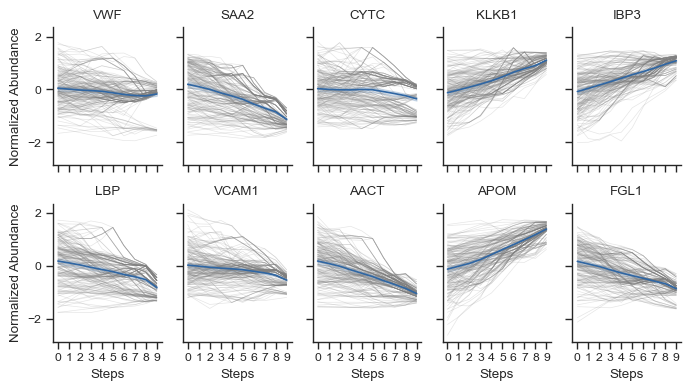

In [35]:
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=1)


fig, axs = plt.subplots(
    nrows=2,
    ncols=5,
    sharey=True,
    sharex=True,
)

axs = axs.flatten()

for ax, col in enumerate(selected_features):

    for patient_id in results['ID'].unique():

        patient_results = results[results['ID'] == patient_id]

        sns.lineplot(
            data=patient_results,
            x="Steps",
            y=col,
            ax=axs[ax],
            #hue="Future Organ Dysfunction",
            color="gray",
            lw=0.5,
            alpha=0.2
        )

    sns.lineplot(
        data=results,
        x="Steps",
        y=col,
        ax=axs[ax],
        #hue="Future Organ Dysfunction",
        color="#2F66A3"
    )

    axs[ax].set_ylabel("Normalized Abundance")

    if col == "AACT":

        axs[ax].set_xlabel("Steps")

    else:
        axs[ax].set_label("")

    axs[ax].set_title(col.split("_")[0])
    axs[ax].set_xticks(np.arange(10))

sns.despine()
fig.set_size_inches((7, 4))
plt.tight_layout()
plt.show()

In [36]:
fig.savefig(
    "general_protein_trends.pdf", dpi=300, bbox_inches="tight", transparent=True
)

In [37]:
from fa2_modified import ForceAtlas2
import matplotlib.pyplot as plt
import networkx as nx

G = df_estimator.network_

positions = nx.forceatlas2_layout(
    G,
    max_iter=1000,
    seed=0,
    #strong_gravity=True,
    dissuade_hubs=True
)

In [38]:
display_columns = [
    "Sepsis Rates",
    "Infection Rates",
    "Future Organ Dysfunction",
    "30 Day Mortality",
    "ICU"
]

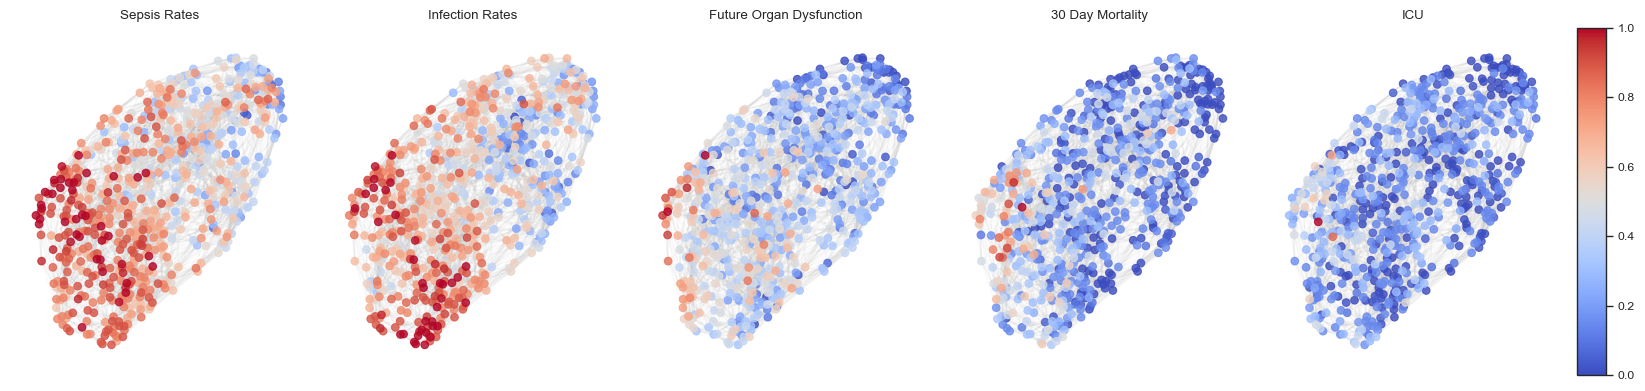

In [39]:
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=6,
    gridspec_kw={'width_ratios': [1, 1, 1, 1, 1, 0.1]}
)

for i, col in enumerate(display_columns):

    # values = training_data[col].to_numpy()
    # cmap = plt.cm.coolwarm
    # norm = plt.Normalize(vmin=training_data[col].min(), vmax=training_data[col].max())
    # colors = cmap(norm(values))

    color_normalizer = MinMaxScaler((0, 1))

    values = MinMaxScaler().fit_transform(training_data[[col]])

    color_map = dict(zip(training_data.index, values))
    ordered_nodes = list(training_data.sort_values(col, ascending=True).index)

    node_colors = [color_map[node] for node in ordered_nodes]

    nx.draw_networkx_nodes(G, positions, node_size=30, node_color=node_colors, nodelist=ordered_nodes, cmap="coolwarm", alpha=0.8, ax=axs[i])
    nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=axs[i])

    axs[i].axis("off")

    axs[i].set_title(col)



sm = plt.cm.ScalarMappable(cmap="coolwarm")
cbar = fig.colorbar(sm, cax=axs[-1], orientation="vertical")


fig.set_size_inches((8.27 * 2, 4))
plt.tight_layout()

fig.savefig(
    "sepsis_df_model_maps.pdf",
    bbox_inches="tight",
    transparent=True,
    dpi=300,
)

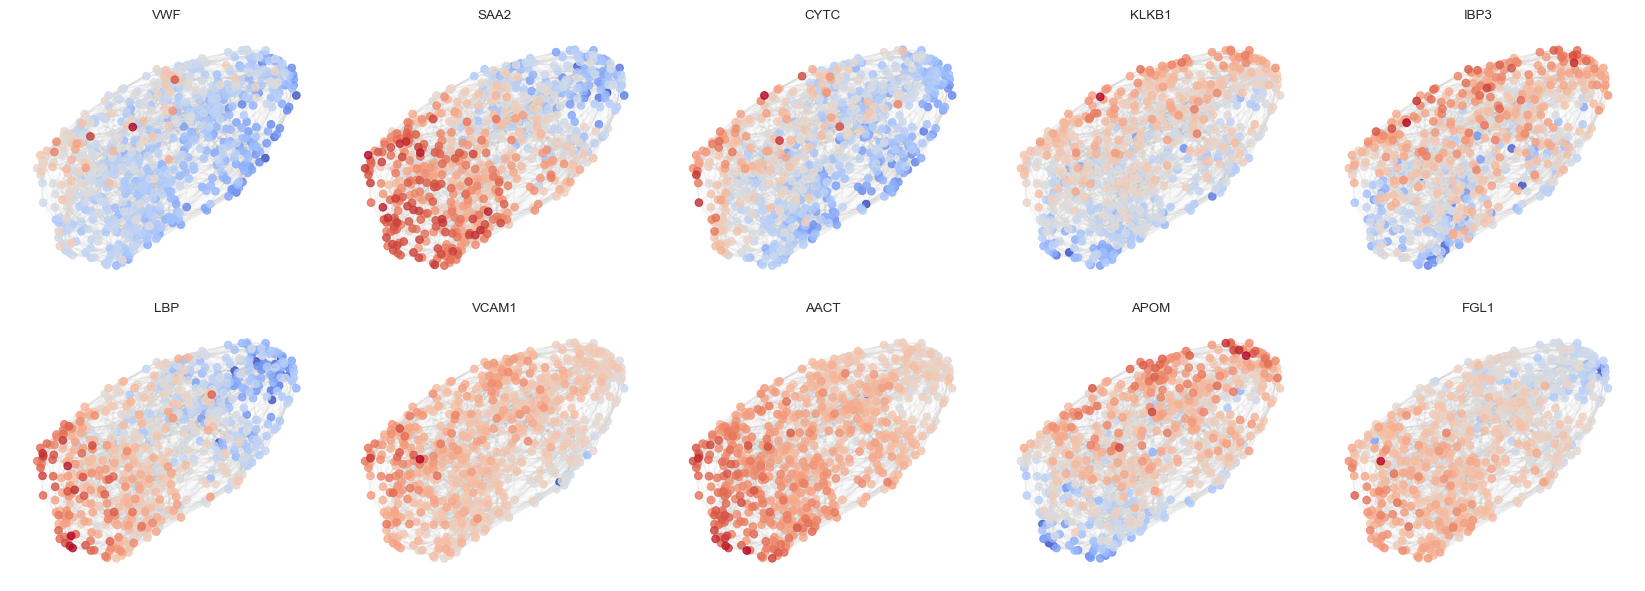

In [40]:
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=2,
    ncols=5,
    #gridspec_kw={'width_ratios': [1, 1, 1, 1, 1, 0.1]}
)

axs = axs.flatten()

for i, col in enumerate(selected_features):
    # values = training_data[col].to_numpy()
    # cmap = plt.cm.coolwarm
    # norm = plt.Normalize(vmin=training_data[col].min(), vmax=training_data[col].max())
    # colors = cmap(norm(values))

    color_normalizer = MinMaxScaler((0, 1))

    values = MinMaxScaler().fit_transform(training_data[[col]])

    color_map = dict(zip(training_data.index, values))
    ordered_nodes = list(training_data.sort_values(col, ascending=True).index)

    node_colors = [color_map[node] for node in ordered_nodes]

    nx.draw_networkx_nodes(G, positions, node_size=30, node_color=node_colors, nodelist=ordered_nodes, cmap="coolwarm",
                           alpha=0.8, ax=axs[i])
    nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=axs[i])

    axs[i].axis("off")

    axs[i].set_title(col[:-6])

# sm = plt.cm.ScalarMappable(cmap="coolwarm")
# cbar = fig.colorbar(sm, cax=axs[-1], orientation="vertical")

fig.set_size_inches((8.27 * 2, 6))
plt.tight_layout()

fig.savefig(
    "sepsis_df_protein_maps.pdf",
    bbox_inches="tight",
    transparent=True,
    dpi=300,
)

In [41]:
worst_list = list(testing_data.sort_values("Future Organ Dysfunction", ascending=False).head(1).index)

In [42]:
positions[100]

array([-543.6255 , -187.95084], dtype=float32)

In [43]:
subset_paths = dict()

count = 0

subset_paths[worst_list[0]] = shortest_paths[worst_list[0]]

# for key in worst_list:
#
#     if positions[key][0] < -400:
#
#         print("here")
#
#         subset_paths[key] = shortest_paths[key]
#
#         break
#
#
# for key in worst_list:
#
#     if positions[key][0] < -420:
#
#         print("here")
#
#         subset_paths[key] = shortest_paths[key]
#
#         break


In [44]:
positions[45]

array([-404.61972 ,   56.192486], dtype=float32)

In [45]:
subset_paths

{41: [680, 377, 624, 324, 628, 448]}

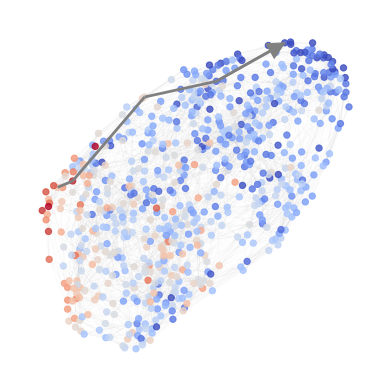

In [46]:
from matplotlib.collections import LineCollection
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

col = "Future Organ Dysfunction"

# values = training_data[col].to_numpy()
# cmap = plt.cm.coolwarm
# norm = plt.Normalize(vmin=training_data[col].min(), vmax=training_data[col].max())
# colors = cmap(norm(values))

color_normalizer = MinMaxScaler((0, 1))

values = MinMaxScaler().fit_transform(training_data[[col]])

color_map = dict(zip(training_data.index, values))
node_colors = [color_map[node] for node in G.nodes()]

nx.draw_networkx_nodes(G, positions, node_size=20, node_color=node_colors, cmap="coolwarm", alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=ax, width=0.4)

for idx, path in subset_paths.items():
#
    edge_list = list(zip(path[1:], path[2:]))
#
#     nx.draw_networkx_edges(
#         G,
#         positions,
#         edgelist=edge_list,
#         edge_color="gray",
#         arrows=True,
#         arrowstyle="->",
#         arrowsize=20,
#         node_shape="x",
#         width=3,
#     )

    edge_lines = [(positions[u], positions[v]) for u, v in edge_list]
    lc = LineCollection(edge_lines, colors='gray', linewidths=2, zorder=3)
    ax.add_collection(lc)

    ax.annotate(
        "",
        xytext=edge_lines[-1][0],
        xy=edge_lines[-1][1],
        arrowprops=dict(
            #arrowstyle="->",
            width=1,
            color="gray"
        ),
    )

    # nx.draw_networkx_nodes(G, positions, nodelist=[edge_lines[0][0]], node_size=30, node_shape="x", node_color=node_colors, cmap="coolwarm", alpha=0.8, ax=ax)
    #


axs[i].axis("off")

axs[i].set_title(col)

sm = plt.cm.ScalarMappable(cmap="coolwarm")
cbar = fig.colorbar(sm, ax=axs[i], orientation="horizontal")

#cbar = fig.colorbar(ax=axs[i])

fig.set_size_inches((4, 4))
plt.axis('off')
plt.tight_layout()

In [47]:
edge_list

[(377, 624), (624, 324), (324, 628), (628, 448)]

In [48]:
fig.savefig(
    "all_validation_pathways.pdf", dpi=300, bbox_inches="tight"
)

In [49]:
worst_list

[41]

In [50]:
patient_results = results[results['ID'] == worst_list[0]]

In [51]:
patient_results

,VWF_HUMAN,SAA2_HUMAN,CYTC_HUMAN,KLKB1_HUMAN,IBP3_HUMAN,LBP_HUMAN,VCAM1_HUMAN,AACT_HUMAN,APOM_HUMAN,FGL1_HUMAN,Steps,ID,Future Organ Dysfunction,30 Day Mortality,ICU
0,0.527993,1.126899,1.608920,-0.211755,-0.328265,1.257569,0.841049,1.567600,-1.304541,1.116201,0,41,0.7343,0.211,0.2714
1,0.780485,1.104608,1.564551,0.074970,0.130954,1.307319,0.864425,1.304568,-0.596741,0.792829,1,41,0.7343,0.211,0.2714
2,1.032977,1.082316,1.520182,0.361695,0.590174,1.357070,0.887802,1.041537,0.111059,0.469456,2,41,0.7343,0.211,0.2714
3,1.107804,0.998090,1.552898,0.327536,0.479955,1.404060,0.995819,1.039459,0.000357,-0.125002,3,41,0.7343,0.211,0.2714
4,1.182631,0.913864,1.585613,0.293377,0.369737,1.451049,1.103836,1.037381,-0.110344,-0.719460,4,41,0.7343,0.211,0.2714
5,0.948369,0.352011,1.307347,0.934932,0.824573,0.882486,0.849152,0.428940,0.378370,-0.613823,5,41,0.7343,0.211,0.2714
6,0.714108,-0.209842,1.029081,1.576488,1.279408,0.313922,0.594468,-0.179502,0.867084,-0.508185,6,41,0.7343,0.211,0.2714
7,0.207622,-0.289569,0.679192,1.170826,1.188225,0.153200,0.224520,-0.477549,1.010980,-0.495267,7,41,0.7343,0.211,0.2714
8,-0.298864,-0.369296,0.329302,0.765165,1.097043,-0.007522,-0.145429,-0.775596,1.154876,-0.482349,8,41,0.7343,0.211,0.2714
9,-0.091612,-0.919927,0.112617,1.059670,1.219436,-0.557477,-0.424926,-1.044129,1.410967,-0.807769,9,41,0.7343,0.211,0.2714


In [52]:
melted = patient_results.melt(
    id_vars=["ID", "Steps"],
    value_vars=selected_features
)

In [53]:
test2 = patient_results.set_index("Steps")[selected_features].T

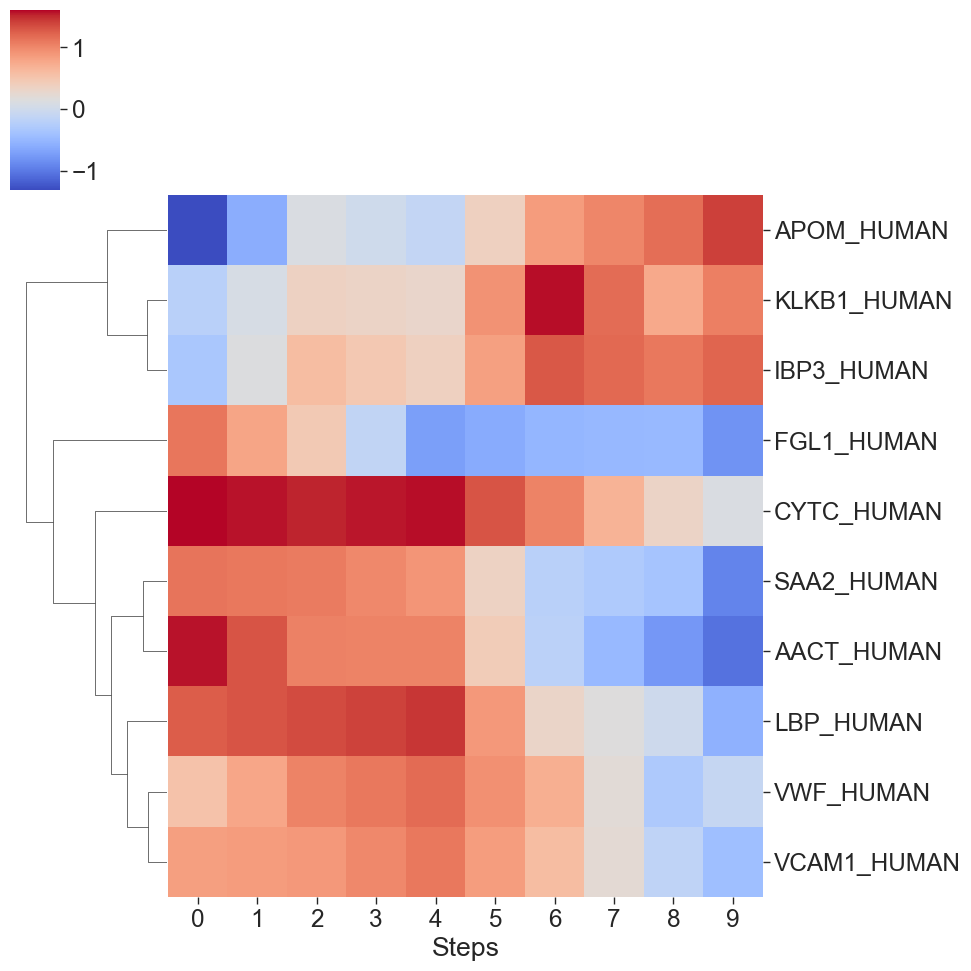

In [54]:
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=2)


fig = sns.clustermap(
    data=test2.astype(float),
    cmap="coolwarm",
    #ax=ax,
    col_cluster=False
)

fig.savefig(
    "patient_specific_pathways.pdf", dpi=300, bbox_inches="tight", transparent=True
)

In [55]:
test = results[selected_features + ["Steps"]].groupby("Steps").mean().T

In [56]:
test = results.pivot(
    columns="Steps",
    index="ID",
    values=selected_features,
)

In [57]:
test

VWF_HUMAN                                                              \
Steps         0         1         2         3         4         5         6   
ID                                                                            
0      0.300440  0.256551  0.212663  0.276304  0.339945 -0.080168 -0.500282   
4     -0.506919 -0.466181 -0.425444 -0.384706 -0.343969 -0.303232 -0.247249   
5      0.338763  0.498460  0.507969  0.217099  0.208063  0.339945 -0.164191   
6      0.343777  0.157298 -0.029181 -0.190880 -0.352578 -0.426430 -0.500282   
7      0.403746  0.319102  0.234459  0.135593  0.022505 -0.090584 -0.173896   
..          ...       ...       ...       ...       ...       ...       ...   
247    0.041950  0.006384 -0.029181 -0.190880 -0.352578 -0.426430 -0.500282   
248   -0.091752  0.277612  0.483185  0.522150  0.298539  0.251800  0.197612   
249   -0.540420 -0.641076 -0.729374 -0.792954 -0.839567 -0.877697 -0.538988   
250   -0.449722 -0.577207 -0.704693 -0.832178 -0.759512 -0.586769 -0.414026   
252   -0.211342 -0.229076 -0.246809 -0.264543 -0.276136 -0.284659 -0.293182   

                                     ... FGL1_HUMAN                      \
Steps         7         8         9  ...          0         1         2   
ID                                   ...                                  
0     -0.399573 -0.298864 -0.091612  ...   0.185373  0.298952  0.412532   
4     -0.191266 -0.135283 -0.079300  ...  -0.577926 -0.631995 -0.686064   
5     -0.459998 -0.339147 -0.133062  ...   0.524819  0.299359  0.189625   
6     -0.399573 -0.298864 -0.091612  ...   1.089520  0.910572  0.731625   
7     -0.257208 -0.215963 -0.050161  ...  -0.019190 -0.171937 -0.324685   
..          ...       ...       ...  ...        ...       ...       ...   
247   -0.399573 -0.298864 -0.091612  ...   1.097337  0.914481  0.731625   
248   -0.052073 -0.056812 -0.032330  ...   0.809429  0.811716  0.642147   
249   -0.288100 -0.212854 -0.121990  ...   0.648215  0.587019  0.488829   
250   -0.257413 -0.133062 -0.008711  ...  -0.709950 -0.728300 -0.746651   
252   -0.257413 -0.133062 -0.008711  ...  -0.252014 -0.282237 -0.312460   

                                                                             
Steps         3         4         5         6         7         8         9  
ID                                                                           
0      0.341992  0.271452  0.100750 -0.069951 -0.276150 -0.482349 -0.807769  
4     -0.740134 -0.794203 -0.848272 -0.823615 -0.798958 -0.774302 -0.749645  
5      0.311341  0.319728  0.271452  0.066610 -0.152431 -0.399869 -0.742685  
6      0.614165  0.496705  0.213377 -0.069951 -0.276150 -0.482349 -0.807769  
7     -0.455798 -0.565275 -0.674752 -0.597791 -0.520829 -0.612517 -0.872852  
..          ...       ...       ...       ...       ...       ...       ...  
247    0.614165  0.496705  0.213377 -0.069951 -0.276150 -0.482349 -0.807769  
248    0.337481 -0.004414 -0.266449 -0.500269 -0.743415 -0.976417 -0.993512  
249    0.316648  0.125235 -0.075795 -0.254927 -0.321394 -0.162529 -0.355739  
250   -0.765001 -0.713364 -0.626733 -0.540103 -0.547433 -0.742685 -0.937936  
252   -0.342684 -0.378676 -0.417553 -0.456431 -0.547433 -0.742685 -0.937936  

[200 rows x 100 columns]

In [58]:
feature_diff_columns = []

for feature in selected_features:

    test[f'{feature}_diff'] = test[feature][9] - test[feature][0]

    feature_diff_columns.append(f'{feature}_diff')

In [59]:
test["Future Organ Dysfunction"] = testing_data.loc[test.index, "Future Organ Dysfunction"]

In [60]:
organ_dysfunction_cmap = sns.color_palette("magma", n_colors=test["Future Organ Dysfunction"].unique().shape[0])

In [61]:
organ_dysfunction_cmap

[(0.002258, 0.001295, 0.018331),
 (0.003279, 0.002305, 0.023708),
 (0.004512, 0.00349, 0.029965),
 (0.007588, 0.006356, 0.044973),
 (0.009426, 0.008022, 0.052844),
 (0.011465, 0.009828, 0.06075),
 (0.016156, 0.01384, 0.076603),
 (0.018815, 0.016026, 0.084584),
 (0.021692, 0.01832, 0.09261),
 (0.024792, 0.020715, 0.100676),
 (0.031696, 0.025765, 0.116965),
 (0.03552, 0.028397, 0.125209),
 (0.039608, 0.03109, 0.133515),
 (0.048062, 0.036607, 0.150327),
 (0.05232, 0.039407, 0.158841),
 (0.056615, 0.04216, 0.167446),
 (0.060949, 0.044794, 0.176129),
 (0.069764, 0.049726, 0.193735),
 (0.074257, 0.052017, 0.20266),
 (0.078815, 0.054184, 0.211667),
 (0.088155, 0.058133, 0.229922),
 (0.092949, 0.059904, 0.239164),
 (0.097833, 0.061531, 0.248477),
 (0.102815, 0.06301, 0.257854),
 (0.113094, 0.065492, 0.276784),
 (0.118405, 0.066479, 0.286321),
 (0.123833, 0.067295, 0.295879),
 (0.135053, 0.068391, 0.315),
 (0.140858, 0.068654, 0.324538),
 (0.146785, 0.068738, 0.334011),
 (0.152839, 0.068637, 0.343404),
 (0.165308, 0.067911, 0.361816),
 (0.171713, 0.067305, 0.370771),
 (0.178212, 0.066576, 0.379497),
 (0.19146, 0.064818, 0.396152),
 (0.198177, 0.063862, 0.404009),
 (0.204935, 0.062907, 0.411514),
 (0.211718, 0.061992, 0.418647),
 (0.225302, 0.060445, 0.431742),
 (0.232077, 0.059889, 0.437695),
 (0.238826, 0.059517, 0.443256),
 (0.25222, 0.059415, 0.453248),
 (0.258857, 0.059706, 0.45771),
 (0.265447, 0.060237, 0.46184),
 (0.271994, 0.060994, 0.46566),
 (0.284951, 0.063168, 0.472451),
 (0.291366, 0.064553, 0.475462),
 (0.29774, 0.066117, 0.478243),
 (0.310382, 0.069702, 0.483186),
 (0.316654, 0.07169, 0.48538),
 (0.322899, 0.073782, 0.487408),
 (0.329114, 0.075972, 0.489287),
 (0.341482, 0.080564, 0.492631),
 (0.347636, 0.082946, 0.494121),
 (0.353773, 0.085373, 0.495501),
 (0.366012, 0.090314, 0.49796),
 (0.372116, 0.092816, 0.499053),
 (0.378211, 0.095332, 0.500067),
 (0.384299, 0.097855, 0.501002),
 (0.396467, 0.102902, 0.502658),
 (0.402548, 0.10542, 0.503386),
 (0.408629, 0.10793, 0.504052),
 (0.420791, 0.11292, 0.505215),
 (0.426877, 0.115395, 0.505714),
 (0.432967, 0.117855, 0.50616),
 (0.439062, 0.120298, 0.506555),
 (0.451271, 0.125132, 0.507198),
 (0.457386, 0.127522, 0.507448),
 (0.463508, 0.129893, 0.507652),
 (0.47578, 0.134577, 0.507921),
 (0.481929, 0.136891, 0.507989),
 (0.488088, 0.139186, 0.508011),
 (0.494258, 0.141462, 0.507988),
 (0.506629, 0.145958, 0.507806),
 (0.512831, 0.148179, 0.507648),
 (0.519045, 0.150383, 0.507443),
 (0.531507, 0.154739, 0.506895),
 (0.537755, 0.156894, 0.506551),
 (0.544015, 0.159033, 0.506159),
 (0.550287, 0.161158, 0.505719),
 (0.562866, 0.165368, 0.504692),
 (0.569172, 0.167454, 0.504105),
 (0.57549, 0.16953, 0.503466),
 (0.588158, 0.173652, 0.502035),
 (0.594508, 0.175701, 0.501241),
 (0.600868, 0.177743, 0.500394),
 (0.607238, 0.179779, 0.499492),
 (0.620005, 0.18384, 0.497524),
 (0.626401, 0.185867, 0.496456),
 (0.632805, 0.187893, 0.495332),
 (0.645633, 0.191952, 0.49291),
 (0.652056, 0.193986, 0.491611),
 (0.658483, 0.196027, 0.490253),
 (0.664915, 0.198075, 0.488836),
 (0.677786, 0.202203, 0.485819),
 (0.684224, 0.204286, 0.484219),
 (0.690661, 0.206384, 0.482558),
 (0.703532, 0.210638, 0.479049),
 (0.709962, 0.212797, 0.477201),
 (0.716387, 0.214982, 0.47529),
 (0.722805, 0.217194, 0.473316),
 (0.735616, 0.221713, 0.46918),
 (0.742004, 0.224025, 0.467018),
 (0.748378, 0.226377, 0.464794),
 (0.761077, 0.231214, 0.460162),
 (0.767398, 0.233705, 0.457755),
 (0.773695, 0.236249, 0.455289),
 (0.779968, 0.238851, 0.452765),
 (0.792427, 0.244242, 0.447543),
 (0.798608, 0.24704, 0.444848),
 (0.804752, 0.249911, 0.442102),
 (0.816914, 0.255895, 0.436461),
 (0.822926, 0.259016, 0.433573),
 (0.828886, 0.262229, 0.430644),
 (0.834791, 0.26554, 0.427671),
 (0.846416, 0.272473, 0.421631),
 (0.852126, 0.276106, 0.418573),
 (0.857763, 0.279857, 0.415496),
 (0.868793, 0.287728, 0.409303),
 (0.874176, 0.291859, 0.406205),
 (0.879464, 0.296125, 0.403118),
 (0.884651, 0.30053, 0.400047),
 (0.8947, 0

In [62]:
lut = dict(zip(test["Future Organ Dysfunction"].unique(), organ_dysfunction_cmap))
row_colors = test["Future Organ Dysfunction"].map(lut)

In [63]:

from scipy.stats import linregress

x = np.arange(10)

def calc_slope(row):
    slope, intercept, r_value, p_value, std_err = linregress(x, row)
    return slope




In [64]:
protein_slope_cols = []

for col in selected_features:

    test[f"{col}_slope"] = test[col].apply(calc_slope, axis=1)

    protein_slope_cols.append(f"{col}_slope")

In [65]:
protein_slope_cols

['VWF_HUMAN_slope',
 'SAA2_HUMAN_slope',
 'CYTC_HUMAN_slope',
 'KLKB1_HUMAN_slope',
 'IBP3_HUMAN_slope',
 'LBP_HUMAN_slope',
 'VCAM1_HUMAN_slope',
 'AACT_HUMAN_slope',
 'APOM_HUMAN_slope',
 'FGL1_HUMAN_slope']

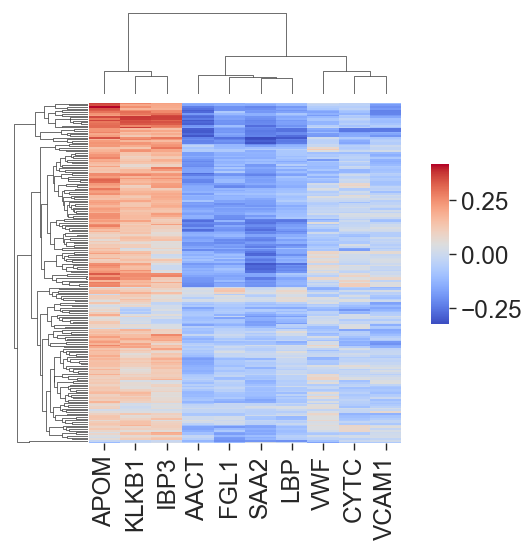

In [66]:
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=2)

g = sns.clustermap(
    data=test[protein_slope_cols],
    cmap="coolwarm",
    figsize=(6, 8),
    #col_cluster=False,
    #row_colors=row_colors,
    #ax=ax
)

g.ax_heatmap.set_ylabel("")
g.ax_heatmap.set_yticks([])
g.ax_heatmap.set_yticklabels([])

g.ax_heatmap.set_xticklabels(
    [label.get_text()[:-13] for label in g.ax_heatmap.get_xticklabels()],
)

g.ax_heatmap.set_xlabel("")

g.fig.subplots_adjust(right=0.7)
g.ax_cbar.set_position((0.75, .57, .03, .2))

g.fig.savefig(
    "clustered_patient_slopes.pdf",
    bbox_inches="tight",
    transparent=True,
    dpi=300,
)